In [1]:
!pip install -U langgraph langchain langchain-google-genai langchain-chroma langchain-huggingface sentence-transformers chromadb

In [2]:
import os
import json
import operator
from typing import TypedDict, Annotated, List, Dict, Any, Literal

from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_chroma import Chroma
from langchain_core.documents import Document

from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver


In [3]:
import os
from google import genai
from google.colab import userdata

#API_KEY = put the new api key here created latest
api_key = userdata.get("GOOGLE_API_KEY")
#client = genai.Client(api_key=api_key)
os.environ["GOOGLE_API_KEY"] = api_key
# ---------------------------------------
# 1. API KEY
# ---------------------------------------
# In Colab:
# import getpass
# os.environ["GOOGLE_API_KEY"] = getpass.getpass("Enter Gemini API key: ")

if "GOOGLE_API_KEY" not in os.environ:
    raise ValueError("Please set GOOGLE_API_KEY first.")

# -------------------------------
# 1. SET GEMINI API KEY
# -------------------------------
# In Colab:
# import getpass
# os.environ["GOOGLE_API_KEY"] = getpass.getpass("Enter Gemini API key: ")

if "GOOGLE_API_KEY" not in os.environ:
    raise ValueError("Set GOOGLE_API_KEY first")


In [4]:


# -------------------------------
# 2. FRAUD KNOWLEDGE BASE
# -------------------------------
docs = [
    Document(
        page_content="""
        High value transaction fraud rule:
        Transactions above Rs 1,00,000 from a new device or unusual location
        should be marked high risk and sent for enhanced verification.
        """,
        metadata={"topic": "high_value_transaction"}
    ),
    Document(
        page_content="""
        Velocity fraud rule:
        More than 5 transactions within 10 minutes may indicate card testing,
        account takeover, bot activity, or stolen credential usage.
        """,
        metadata={"topic": "velocity_fraud"}
    ),
    Document(
        page_content="""
        Geo anomaly fraud rule:
        If the user normally transacts from India but suddenly transacts from
        another country, especially with a new device, escalate for review.
        """,
        metadata={"topic": "geo_anomaly"}
    ),
    Document(
        page_content="""
        Account freeze policy:
        Freeze account only if risk is critical, such as stolen credentials,
        multiple suspicious attempts, impossible travel, blacklisted merchant,
        or human fraud analyst approval.
        """,
        metadata={"topic": "account_freeze"}
    ),
    Document(
        page_content="""
        Low confidence rule:
        If fraud confidence is below 0.70, retrieve more policies and repeat
        the fraud analysis before making a final decision.
        """,
        metadata={"topic": "low_confidence"}
    )
]


# -------------------------------
# 3. CHROMADB VECTOR DATABASE
# -------------------------------
embedding = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

vector_db = Chroma.from_documents(
    documents=docs,
    embedding=embedding,
    collection_name="fintech_fraud_kb",
    persist_directory="./chroma_fintech_fraud"
)

retriever = vector_db.as_retriever(search_kwargs={"k": 2})

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [21]:



# -------------------------------
# 4. GEMINI LLM
# -------------------------------
llm = ChatGoogleGenerativeAI(
    #model="gemini-1.5-flash",
    model="gemini-2.5-flash",
    temperature=0.2,
    max_retries=0
)


# -------------------------------
# 5. LANGGRAPH STATE
# -------------------------------
class FraudState(TypedDict):
    transaction_id: str
    customer_id: str
    transaction: Dict[str, Any]

    fraud_flags: List[str]
    route: str

    retrieved_docs: Annotated[List[str], operator.add]

    fraud_analysis: str
    confidence: float
    risk_score: int

    retry_count: int
    fraud_critical: bool

    human_review_required: bool
    human_approved_block: bool

    action: str
    final_report: str

    state_log: Annotated[List[str], operator.add]


def log(message: str) -> List[str]:
    return [message]


# -------------------------------
# 6. STORE TRANSACTION STATE
# -------------------------------
def store_transaction_state(state: FraudState):
    return {
        "state_log": log(
            f"Stored transaction state for {state['transaction_id']}"
        )
    }


# -------------------------------
# 7. RULE-BASED FRAUD CHECK
# -------------------------------
def rule_based_fraud_check(state: FraudState):
    tx = state["transaction"]
    flags = []

    if tx["amount"] >= 100000:
        flags.append("HIGH_VALUE_TRANSACTION")

    if tx["is_new_device"]:
        flags.append("NEW_DEVICE")

    if tx["country"] != tx["usual_country"]:
        flags.append("GEO_ANOMALY")

    if tx["transactions_last_10_min"] > 5:
        flags.append("VELOCITY_FRAUD")

    if tx["merchant_blacklisted"]:
        flags.append("BLACKLISTED_MERCHANT")

    fraud_critical = (
        "BLACKLISTED_MERCHANT" in flags
        or ("HIGH_VALUE_TRANSACTION" in flags and "NEW_DEVICE" in flags and "GEO_ANOMALY" in flags)
        or ("VELOCITY_FRAUD" in flags and "NEW_DEVICE" in flags)
    )

    return {
        "fraud_flags": flags,
        "fraud_critical": fraud_critical,
        "state_log": log(f"Fraud rules checked. Flags={flags}, critical={fraud_critical}")
    }


# -------------------------------
# 8. ROUTER: SELECT FRAUD PATH
# -------------------------------
def fraud_route(state: FraudState) -> Literal["high_value", "velocity", "geo", "general"]:
    flags = state["fraud_flags"]

    if "HIGH_VALUE_TRANSACTION" in flags:
        return "high_value"

    if "VELOCITY_FRAUD" in flags:
        return "velocity"

    if "GEO_ANOMALY" in flags:
        return "geo"

    return "general"


# -------------------------------
# 9. RETRIEVAL NODES
# -------------------------------
def retrieve_high_value_policy(state: FraudState):
    results = retriever.invoke("high value transaction new device fraud policy")
    return {
        "route": "high_value",
        "retrieved_docs": [doc.page_content for doc in results],
        "state_log": log("Retrieved high-value transaction fraud policies.")
    }


def retrieve_velocity_policy(state: FraudState):
    results = retriever.invoke("velocity fraud multiple transactions card testing")
    return {
        "route": "velocity",
        "retrieved_docs": [doc.page_content for doc in results],
        "state_log": log("Retrieved velocity fraud policies.")
    }


def retrieve_geo_policy(state: FraudState):
    results = retriever.invoke("geo anomaly impossible travel country change fraud")
    return {
        "route": "geo",
        "retrieved_docs": [doc.page_content for doc in results],
        "state_log": log("Retrieved geo-anomaly fraud policies.")
    }


def retrieve_general_policy(state: FraudState):
    results = retriever.invoke("general transaction fraud detection policy")
    return {
        "route": "general",
        "retrieved_docs": [doc.page_content for doc in results],
        "state_log": log("Retrieved general fraud policies.")
    }


# -------------------------------
# 10. GEMINI FRAUD ANALYSIS
# -------------------------------
def llm_fraud_analysis(state: FraudState):
    prompt = f"""
You are a fintech fraud detection analyst.

Transaction:
{json.dumps(state["transaction"], indent=2)}

Fraud flags:
{state["fraud_flags"]}

Retrieved fraud policies:
{chr(10).join(state["retrieved_docs"])}

Return ONLY valid JSON:
{{
  "fraud_analysis": "...",
  "confidence": 0.0,
  "risk_score": 0,
  "recommended_action": "..."
}}

Rules:
- risk_score must be between 0 and 100.
- If blacklisted merchant exists, recommend block.
- If fraud is critical, recommend human review before account freeze.
- If confidence is low, say more policy evidence is needed.
"""

    try:
        response = llm.invoke(prompt)
        raw = response.content.strip()
        raw = raw.replace("```json", "").replace("```", "").strip()
        parsed = json.loads(raw)

        return {
            "fraud_analysis": parsed.get("fraud_analysis", ""),
            "confidence": float(parsed.get("confidence", 0.5)),
            "risk_score": int(parsed.get("risk_score", 50)),
            "action": parsed.get("recommended_action", ""),
            "state_log": log("Gemini fraud analysis completed.")
        }

    except Exception as e:
        return {
            "retry_count": state["retry_count"] + 1,
            "confidence": 0.0,
            "fraud_analysis": f"LLM failed: {str(e)}",
            "state_log": log(f"LLM failed. Retry count={state['retry_count'] + 1}")
        }



In [22]:

# -------------------------------
# 11. ROUTER AFTER LLM
# -------------------------------
def post_llm_router(
    state: FraudState
) -> Literal["retry_llm", "retrieve_more", "human_review", "auto_block", "approve"]:

    if state["confidence"] == 0.0 and state["retry_count"] < 2:
        return "retry_llm"

    if state["confidence"] < 0.70 and state["retry_count"] < 3:
        return "retrieve_more"

    if state["fraud_critical"]:
        return "human_review"

    if state["risk_score"] >= 85:
        return "auto_block"

    return "approve"


# -------------------------------
# 12. RETRIEVE MORE IF CONFIDENCE LOW
# -------------------------------
def retrieve_more_policies(state: FraudState):
    query = f"""
    Additional fraud investigation.
    Flags: {state["fraud_flags"]}
    Transaction: {state["transaction"]}
    """
    results = retriever.invoke(query)

    return {
        "retry_count": state["retry_count"] + 1,
        "retrieved_docs": [doc.page_content for doc in results],
        "state_log": log("Confidence low. Retrieved more policies and looping back.")
    }


# -------------------------------
# 13. HUMAN REVIEW NODE
# -------------------------------
def human_review_node(state: FraudState):
    print("\nFRAUD CRITICAL TRANSACTION")
    print("Transaction ID:", state["transaction_id"])
    print("Customer ID:", state["customer_id"])
    print("Flags:", state["fraud_flags"])
    print("Analysis:", state["fraud_analysis"])
    print("Risk score:", state["risk_score"])
    print("Recommended action:", state["action"])

    decision = input("\nApprove BLOCK/FREEZE? Type YES or NO: ").strip().upper()

    return {
        "human_review_required": True,
        "human_approved_block": decision == "YES",
        "state_log": log(f"Human analyst approval={decision}")
    }


# -------------------------------
# 14. ROUTER AFTER HUMAN REVIEW
# -------------------------------
def human_review_router(state: FraudState) -> Literal["freeze", "approve"]:
    if state["human_approved_block"]:
        return "freeze"
    return "approve"


# -------------------------------
# 15. ACTION NODES
# -------------------------------
def auto_block_transaction(state: FraudState):
    return {
        "action": "BLOCK TRANSACTION. Notify customer for verification.",
        "state_log": log("Transaction automatically blocked due to high risk score.")
    }


def freeze_account(state: FraudState):
    return {
        "action": "BLOCK TRANSACTION AND FREEZE ACCOUNT. Escalate to fraud operations team.",
        "state_log": log("Account freeze executed after human approval.")
    }


def approve_transaction(state: FraudState):
    return {
        "action": "APPROVE TRANSACTION. Continue monitoring customer activity.",
        "state_log": log("Transaction approved.")
    }


# -------------------------------
# 16. FINAL REPORT
# -------------------------------
def final_report(state: FraudState):
    report = f"""
FINTECH FRAUD DETECTION REPORT

Transaction ID: {state["transaction_id"]}
Customer ID: {state["customer_id"]}

Transaction:
{json.dumps(state["transaction"], indent=2)}

Fraud Flags:
{state["fraud_flags"]}

Route:
{state["route"]}

Fraud Analysis:
{state["fraud_analysis"]}

Confidence:
{state["confidence"]}

Risk Score:
{state["risk_score"]}

Fraud Critical:
{state["fraud_critical"]}

Human Review Required:
{state["human_review_required"]}

Human Approved Block:
{state["human_approved_block"]}

Final Action:
{state["action"]}

Execution Log:
{chr(10).join(state["state_log"])}
"""
    return {
        "final_report": report,
        "state_log": log("Final fraud report generated.")
    }


In [23]:


# -------------------------------
# 17. BUILD LANGGRAPH
# -------------------------------
builder = StateGraph(FraudState)

builder.add_node("store_transaction_state", store_transaction_state)
builder.add_node("rule_based_fraud_check", rule_based_fraud_check)

builder.add_node("retrieve_high_value_policy", retrieve_high_value_policy)
builder.add_node("retrieve_velocity_policy", retrieve_velocity_policy)
builder.add_node("retrieve_geo_policy", retrieve_geo_policy)
builder.add_node("retrieve_general_policy", retrieve_general_policy)

builder.add_node("llm_fraud_analysis", llm_fraud_analysis)
builder.add_node("retrieve_more_policies", retrieve_more_policies)

builder.add_node("human_review_node", human_review_node)
builder.add_node("auto_block_transaction", auto_block_transaction)
builder.add_node("freeze_account", freeze_account)
builder.add_node("approve_transaction", approve_transaction)
builder.add_node("final_report", final_report)

builder.add_edge(START, "store_transaction_state")
builder.add_edge("store_transaction_state", "rule_based_fraud_check")

builder.add_conditional_edges(
    "rule_based_fraud_check",
    fraud_route,
    {
        "high_value": "retrieve_high_value_policy",
        "velocity": "retrieve_velocity_policy",
        "geo": "retrieve_geo_policy",
        "general": "retrieve_general_policy"
    }
)

builder.add_edge("retrieve_high_value_policy", "llm_fraud_analysis")
builder.add_edge("retrieve_velocity_policy", "llm_fraud_analysis")
builder.add_edge("retrieve_geo_policy", "llm_fraud_analysis")
builder.add_edge("retrieve_general_policy", "llm_fraud_analysis")

builder.add_conditional_edges(
    "llm_fraud_analysis",
    post_llm_router,
    {
        "retry_llm": "llm_fraud_analysis",
        "retrieve_more": "retrieve_more_policies",
        "human_review": "human_review_node",
        "auto_block": "auto_block_transaction",
        "approve": "approve_transaction"
    }
)

builder.add_edge("retrieve_more_policies", "llm_fraud_analysis")

builder.add_conditional_edges(
    "human_review_node",
    human_review_router,
    {
        "freeze": "freeze_account",
        "approve": "approve_transaction"
    }
)

builder.add_edge("auto_block_transaction", "final_report")
builder.add_edge("freeze_account", "final_report")
builder.add_edge("approve_transaction", "final_report")
builder.add_edge("final_report", END)

checkpointer = InMemorySaver()
app = builder.compile(checkpointer=checkpointer)


In [24]:
# -------------------------------
# 18. TEST TRANSACTION
# -------------------------------
initial_state: FraudState = {
    "transaction_id": "TXN-908877",
    "customer_id": "CUST-10045",

    "transaction": {
        "amount": 185000,
        "currency": "INR",
        "merchant": "Unknown Electronics Store",
        "merchant_blacklisted": True,
        "country": "Vietnam",
        "usual_country": "India",
        "is_new_device": True,
        "transactions_last_10_min": 8,
        "payment_mode": "credit_card",
        "customer_age_days": 780
    },

    "fraud_flags": [],
    "route": "",
    "retrieved_docs": [],

    "fraud_analysis": "",
    "confidence": 0.0,
    "risk_score": 0,

    "retry_count": 0,
    "fraud_critical": False,

    "human_review_required": False,
    "human_approved_block": False,

    "action": "",
    "final_report": "",
    "state_log": []
}

config = {
    "configurable": {
        "thread_id": "fraud-case-TXN-908877"
    }
}

result = app.invoke(initial_state, config=config)

print(result["final_report"])


FRAUD CRITICAL TRANSACTION
Transaction ID: TXN-908877
Customer ID: CUST-10045
Flags: ['HIGH_VALUE_TRANSACTION', 'NEW_DEVICE', 'GEO_ANOMALY', 'VELOCITY_FRAUD', 'BLACKLISTED_MERCHANT']
Analysis: The transaction is highly suspicious and exhibits multiple critical fraud indicators. It involves a high amount (185,000 INR) from a blacklisted merchant, which is a primary red flag. The transaction also originates from a new device and an unusual geographical location (Vietnam vs. India), directly triggering the 'High value transaction fraud rule' which mandates marking it as high risk. Additionally, velocity fraud is detected with 8 transactions in the last 10 minutes. The confluence of a blacklisted merchant, high value, new device, geo-anomaly, and velocity fraud points to a critical fraud attempt.
Risk score: 98
Recommended action: Block transaction immediately due to blacklisted merchant. Send for urgent human review to investigate the account for potential account freeze or further secur

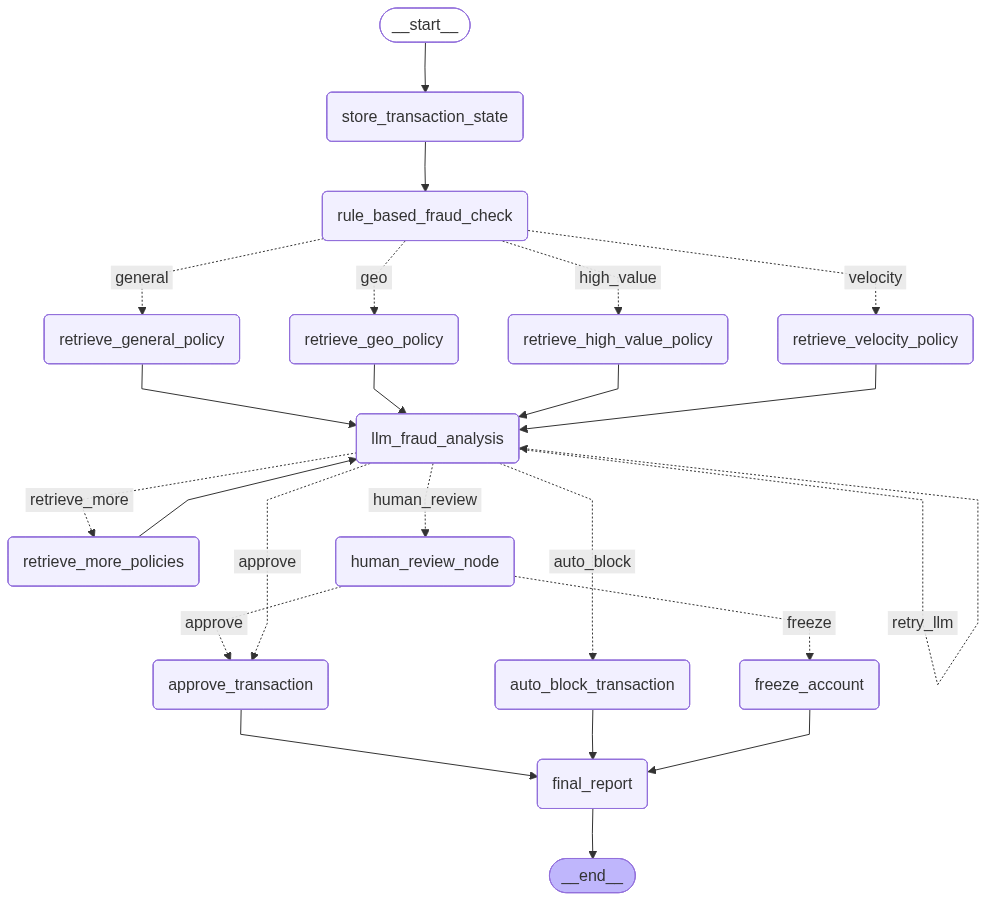

In [25]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))